# 🧭 Clustering de Densidad con DBSCAN: guía detallada y práctica

En este cuaderno aprenderás a detectar regiones densas de datos y distinguir ruido (outliers) usando DBSCAN, un algoritmo de clustering basado en densidad que no requiere fijar el número de clusters.

A lo largo del documento seguiremos un recorrido práctico y razonado: partiremos de los datos crudos, seleccionaremos variables relevantes, las estandarizaremos para que las distancias sean comparables, estimaremos un valor adecuado de ε (epsilon) con el gráfico k‑distancias, ejecutaremos DBSCAN y, finalmente, interpretaremos los resultados desde una perspectiva técnica y de negocio. También revisaremos limitaciones, mejores prácticas y cómo decidir ajustes cuando los resultados no son los esperados.

El enfoque de DBSCAN contrasta con algoritmos de “centroides” como K‑Means: en lugar de forzar formas esféricas y un número k predefinido, DBSCAN busca zonas de alta densidad separadas por regiones de baja densidad, lo que permite capturar formas arbitrarias y detectar ruido de manera natural.

## 🎯 Objetivos y concepto clave

El objetivo principal es identificar automáticamente grupos naturales en los datos sin especificar cuántos hay y, al mismo tiempo, separar el ruido (observaciones aisladas o anómalas). DBSCAN lo consigue definiendo “densidad” local y agrupando puntos que se encuentran en regiones suficientemente pobladas.

Cómo funciona, en pocas ideas pero con profundidad:
- Un vecindario se define por un radio ε (epsilon). Dos puntos son vecinos si su distancia es menor o igual a ε.
- Un punto es “núcleo” si tiene al menos `min_samples` vecinos dentro de ε (incluyéndose a sí mismo en ese conteo en implementaciones comunes). Los núcleos “expanden” clusters.
- Puntos “borde” están cerca de un núcleo pero no alcanzan `min_samples` por sí mismos; se asignan al cluster del núcleo cercano.
- Puntos “ruido” no son núcleo ni borde; quedan sin cluster (etiqueta −1), útil para detectar outliers.

Parámetros fundamentales y sus efectos:
- eps (ε): radio del vecindario. Controla qué tan local es la noción de densidad. ε muy pequeño fragmenta en exceso; ε muy grande fusiona clusters y reduce la detección de ruido.
- min_samples: umbral mínimo de vecinos para ser núcleo. Valores mayores exigen mayor densidad para formar clusters (más conservador frente a ruido). Como regla inicial, usa 2×dimensión o entre 5 y 20 según el tamaño de muestra y ruido esperado.

Intuición práctica: si defino `min_samples = 10`, necesito al menos 10 puntos dentro del radio ε para que un punto sea “central” y empiece a formar un cluster. Ajustar ε y `min_samples` cambia cuánto consideramos “denso”. En escenarios con escalas muy distintas entre variables, estandarizar antes es crucial; de lo contrario, ε medirá casi exclusivamente la variable de mayor magnitud.

## 🌍 ¿Para qué sirve DBSCAN en la vida real?
- Detección de anomalías: transacciones sospechosas, picos de tráfico inusuales, sensores con lectura fuera de patrón, fraudes.
- Descubrir grupos con formas no esféricas (por ejemplo, distribución en “herradura” o “media luna”), donde K‑Means falla.
- Separar ruido de grupos significativos sin definir k, algo útil en exploración de datos cuando no sabemos cuántos clusters esperar.

Buenas prácticas y advertencias:
- Estandariza o normaliza variables si están en magnitudes diferentes; de lo contrario, ε estará dominado por la variable con mayor escala.
- Usa el gráfico k‑distancias para estimar un rango razonable de ε y prueba varios `min_samples` (p. ej., 2×dimensión como punto de partida).
- Revisa el porcentaje de puntos con etiqueta −1 (ruido). Si es demasiado alto, quizá ε es pequeño o `min_samples` demasiado grande; si es casi cero y todo se fusiona, aumenta `min_samples` o reduce ε.
- Datos muy desbalanceados en densidad pueden requerir variantes como HDBSCAN, que ajustan densidad local sin un ε global.
- Considera el costo computacional: DBSCAN necesita calcular vecindarios; con datos muy grandes, evalúa muestreo o estructuras de indexación (k‑d tree, ball tree) vía NearestNeighbors.

In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Miami Housing.csv")
df.head(5)

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4


## 📦 Librerías y carga de datos
Importamos scikit‑learn para DBSCAN y StandardScaler, y cargamos el dataset de viviendas de Miami. Nos centraremos en dos variables numéricas: el precio de venta (`SALE_PRC`) y la edad de la propiedad (`age`). La razón de esta elección es didáctica y práctica: son variables intuitivas, con escalas distintas y con potencial de revelar zonas densas (p. ej., propiedades jóvenes con precios similares y propiedades antiguas con precios agrupados).

Trabajar con pocas variables facilita visualizar y entender el efecto de ε y `min_samples`. En casos reales con más dimensiones, considera reducción de dimensionalidad (PCA) antes de aplicar DBSCAN, siempre manteniendo la escala comparable.

In [39]:
df = df[['SALE_PRC','age']]
df

,SALE_PRC,age
0,440000.0,67
1,349000.0,63
2,800000.0,61
3,988000.0,63
4,755000.0,42
...,...,...
13927,275000.0,16
13928,340000.0,26
13929,287500.0,16
13930,315000.0,16


## 🧩 Selección de variables
Usamos `SALE_PRC` (precio de venta) y `age` (edad). Ambas son numéricas pero de escalas muy distintas; por eso, escalaremos antes de calcular distancias para que ningún eje domine el cálculo. Mantener pocas variables aquí nos permite visualizar y razonar mejor los resultados.

Criterios generales al seleccionar variables para DBSCAN:
- Relevancia: ¿la variable aporta información para distinguir densidades? (p. ej., precio sí, número de baños podría evaluarse)
- Escala: variables con magnitudes dispares requieren estandarización.
- Ruido: variables altamente ruidosas pueden diluir densidad; considera limpiarlas o ponderarlas.

Trabajaremos con un DataFrame solo con esas columnas para simplificar, dejando la puerta abierta a enriquecer el análisis con más atributos en futuras iteraciones.

In [40]:
#Escalamos nuestras variables
Scaler = StandardScaler()
df_scaled = Scaler.fit_transform(df)
df_scaled

array([[ 0.12628516,  1.71757841],
       [-0.16059711,  1.52847376],
       [ 1.261204  ,  1.43392144],
       ...,
       [-0.35447907, -0.69350588],
       [-0.26778388, -0.69350588],
       [-0.47269979,  1.4811976 ]])

## ⚖️ Estandarización de variables
StandardScaler pone cada columna con media 0 y desviación 1. Esto evita que `SALE_PRC` (mucho más grande) domine sobre `age`. Cuando las distancias se calculan en un espacio con ejes de diferente escala, ε mide esencialmente la variable más grande y “aplana” la contribución de las demás.

Consecuencias de no estandarizar:
- ε óptimo se vuelve difícil de interpretar y suele ser extremadamente pequeño o grande.
- DBSCAN puede fusionar todo en un único cluster o marcar casi todo como ruido.

Alternativas y matices:
- RobustScaler si hay outliers severos (media y desviación son sensibles); usa mediana y rango intercuartílico.
- MinMaxScaler si necesitas mantener los datos en [0,1] (útil para visualizar o si ε se define en esa escala).
- En alta dimensión, considera PCA para reducir correlaciones y ruido antes de DBSCAN, manteniendo una varianza explicada razonable.

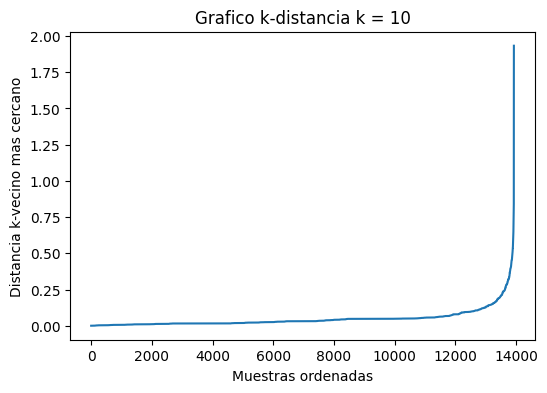

In [41]:
#Graficamos paara elergir el epsilon

from sklearn.neighbors import NearestNeighbors

neighbors= NearestNeighbors(n_neighbors=10)
nbrs = neighbors.fit(df_scaled)
distancias , indices = nbrs.kneighbors(df_scaled)
k_dist = np.sort(distancias[:,9])
plt.figure(figsize=(6,4))
plt.plot(k_dist)
plt.title("Grafico k-distancia k = 10")
plt.xlabel("Muestras ordenadas")
plt.ylabel("Distancia k-vecino mas cercano")
plt.show()

## 📏 Elegir ε con el gráfico k-distancias
El gráfico k‑dist muestra, para cada punto, la distancia a su k‑ésimo vecino más cercano (aquí k=10, alineado con `min_samples`). Ordenamos las distancias de menor a mayor y buscamos un “codo”: un cambio brusco de pendiente. Ese punto sugiere un buen valor de ε: por debajo, los puntos tienden a formar vecindarios densos; por encima, empiezan a separarse.

Cómo leer el gráfico en la práctica:
- Tramo casi horizontal al inicio: regiones densas, distancias pequeñas y similares entre vecinos.
- Codo (aumento súbito): transición desde regiones densas hacia puntos más aislados.
- Tramo con pendiente mayor: distancias que crecen rápido, típico de ruido o regiones menos pobladas.

Sutilezas y recomendaciones:
- No hay un único ε “correcto”; busca un rango razonable y evalúa estabilidad de resultados.
- Ajusta `min_samples` junto con ε: aumentar `min_samples` suele requerir un ε ligeramente mayor para mantener conectividad.
- Si el codo no es claro, prueba varios k (por ejemplo, 5, 10, 15) y busca coherencia entre los codos resultantes.

In [42]:
#Identificar cluster
cluster =  DBSCAN(eps=0.135, min_samples=10).fit_predict(df_scaled)
df['cluster'] = cluster
print(f"Tamaño del DataFrame: {len(df)}")
print(f"Tamaño del array cluster: {len(cluster)}")


Tamaño del DataFrame: 13932
Tamaño del array cluster: 13932


## 🔎 Identificar clusters con DBSCAN
Con los parámetros elegidos (ε y `min_samples`), pedimos a DBSCAN las etiquetas de cada punto. Los valores −1 indican ruido (puntos no asignados a ningún cluster) y los enteros 0, 1, 2, … son los IDs de los clusters encontrados. Un resultado útil no necesita “muchos” clusters; lo importante es que las regiones detectadas tengan sentido de negocio.

Cómo usar las etiquetas para diagnosticar:
- Si casi todo es −1, suele indicar ε pequeño o `min_samples` grande. Intenta subir ε gradualmente o bajar `min_samples`.
- Si todo cae en un único cluster, ε podría ser grande o `min_samples` pequeño. Reduce ε o aumenta `min_samples` para exigir mayor densidad.
- Si aparecen muchos clusters diminutos, revisa outliers y considera robustecer el escalado o depurar datos atípicos.

In [43]:
# 4. Vemos cuántos puntos por cluster
print(df['cluster'].value_counts())

cluster
 0     13171
-1       608
 1        46
 2        27
 5        14
 3        12
 4        11
 7        11
 8        10
 6         8
 9         7
 10        7
Name: count, dtype: int64


## 📊 ¿Cuántos puntos por cluster?
Un conteo rápido de etiquetas nos revela el balance entre clusters y ruido. Heurísticas útiles:
- Ruido razonable: 5% a 30% puede ser aceptable según el dominio; 60% o más sugiere reevaluar ε/`min_samples` o el preprocesamiento.
- Clusters muy pequeños (p. ej., < 1% de las observaciones) podrían ser micro‑grupos o artefactos de outliers; valida con gráficos y conocimiento del negocio.
- Un cluster dominante que engloba casi todo puede ocultar sub‑estructuras; intenta reducir ε o segmentar por subpoblaciones antes de aplicar DBSCAN.

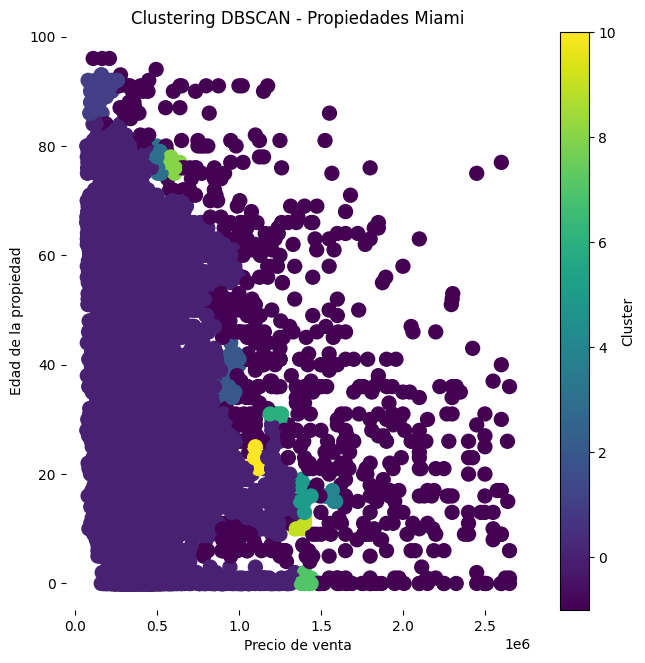

In [46]:
plt.figure(figsize=(7.5,7.5))

plt.scatter(df['SALE_PRC'], df['age'], c=cluster, s=100)
plt.xlabel('Precio de venta')
plt.ylabel('Edad de la propiedad')
plt.colorbar(label='Cluster')
plt.title('Clustering DBSCAN - Propiedades Miami')
plt.box(False)
plt.show()

## 🗺️ Visualizaciones e interpretación
Los diagramas de dispersión colorean cada punto por su etiqueta de cluster. Pautas para leerlos y actuar:
- Manchas compactas del mismo color: clusters densos identificados por DBSCAN; revisa su posición y extensión para entender el perfil (p. ej., propiedades jóvenes y caras vs. antiguas y más baratas).
- Puntos con etiqueta −1: ruido o posibles outliers; pueden ser operaciones atípicas, datos mal capturados o segmentos minoritarios válidos.
- Si hay demasiados −1, aumenta ε o reduce `min_samples`; si todo es un gran cluster, reduce ε o eleva `min_samples`.
- En análisis ejecutivos, acompaña el scatter con estadísticas de cada cluster (medianas, IQR) para traducir colores a mensajes accionables.

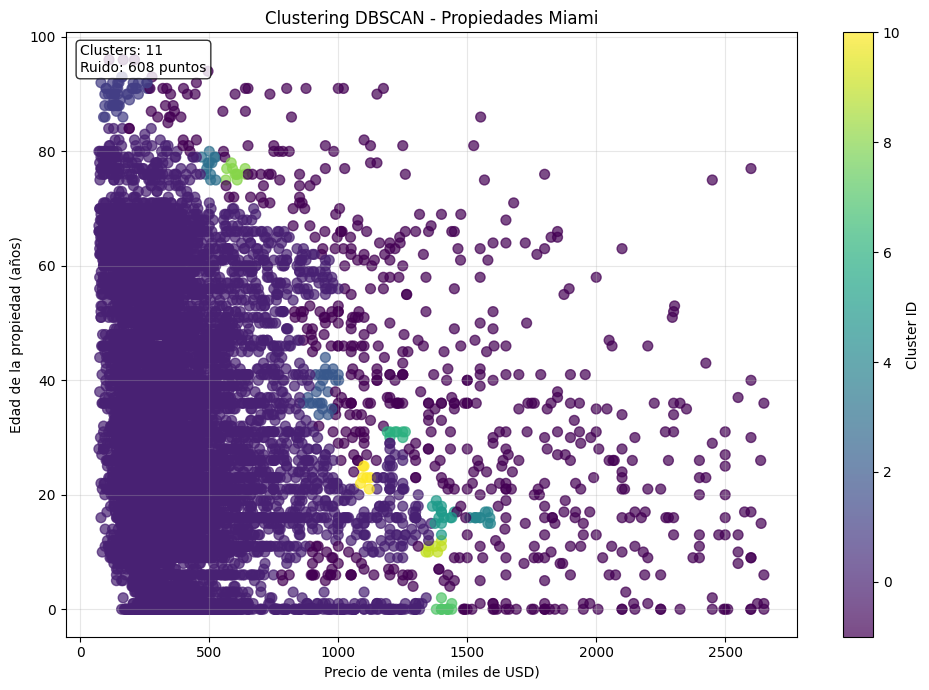

In [47]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(df['SALE_PRC']/1000, df['age'], c=cluster, s=50, cmap='viridis', alpha=0.7)

# Formatear ejes para mejor legibilidad
plt.xlabel('Precio de venta (miles de USD)')
plt.ylabel('Edad de la propiedad (años)')
plt.title('Clustering DBSCAN - Propiedades Miami')

# Agregar grid para mejor lectura
plt.grid(True, alpha=0.3)

# Colorbar con mejor formato
cbar = plt.colorbar(scatter, label='Cluster')
cbar.set_label('Cluster ID')

# Mostrar estadísticas en el gráfico
n_clusters = len(set(cluster)) - (1 if -1 in cluster else 0)
n_noise = list(cluster).count(-1)
plt.text(0.02, 0.98, f'Clusters: {n_clusters}\nRuido: {n_noise} puntos', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## ✅ Conclusiones y recomendaciones
- DBSCAN es ideal para formas arbitrarias y detección de ruido, pero la calidad depende de una buena elección de ε y `min_samples` y de un preprocesamiento cuidadoso (escalado, posibles reducciones de dimensión).
- El gráfico k‑distancias ofrece un buen punto de partida para ε; valida luego con el porcentaje de ruido, la estabilidad de clusters y su interpretabilidad de negocio.
- En presencia de outliers severos o estructuras con densidades muy distintas, evalúa RobustScaler o alternativas como HDBSCAN.
- Para comunicar resultados, complementa con resúmenes por cluster (tamaño, medianas de variables clave) y ejemplos representativos.

Siguientes pasos sugeridos:
- Probar distintos `min_samples` (p. ej., 5, 10, 15) y observar cambios en clusters y ruido.
- Explorar añadir variables (p. ej., metros cuadrados, ubicación) y/o aplicar PCA para sintetizar dimensiones.
- Validar estabilidad con re‑muestras o splits temporales si los datos tienen dimensión temporal.